### [Python Cheat Sheet for Market Data Analysis](https://medium.com/coding-nexus/3b32a18b5936)

##### **Load Historical Stock Data**

In [1]:
# @title {"display-mode":"form"}
import math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

# Download NVDA data from Jan 1, 2023 to Dec 31, 2025
data = yf.download("NVDA", start="2023-01-01", end="2025-12-31", progress=False)

# Check for successful data load
if data.empty:
    print("Error: No data downloaded. Check ticker or internet connection.")
else:
    print("Data loaded successfully!")

Data loaded successfully!


##### **Inspect the Data**

In [2]:
# @title {"display-mode":"form"}
display(data.head())

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2023-01-03,14.300685,14.981005,14.081904,14.836149,401277000
2023-01-04,14.734252,14.838148,14.226761,14.552435,431324000
2023-01-05,14.250734,14.549435,14.133851,14.476508,389168000
2023-01-06,14.844140,14.994989,14.019965,14.459525,405044000
2023-01-09,15.612370,16.039942,15.125857,15.268715,504231000


In [3]:
# @title {"display-mode":"form"}
display(data.tail())

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2025-12-23,189.210007,189.330002,182.899994,182.970001,174873600
2025-12-24,188.610001,188.910004,186.589996,187.940002,65528500
2025-12-26,190.529999,192.690002,188.000000,189.919998,139740300
2025-12-29,188.220001,188.759995,185.910004,187.710007,120006100
2025-12-30,187.539993,188.990005,186.929993,188.240005,97687300


In [4]:
# @title {"display-mode":"form"}
display(data.describe())

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
count,751.000000,751.000000,751.000000,751.000000,7.510000e+02
mean,99.308268,100.941747,97.476993,99.317533,3.575348e+08
std,53.812226,54.579616,53.012152,53.922833,1.764237e+08
min,14.250734,14.549435,14.019965,14.459525,6.552850e+07
25%,45.640297,46.212187,44.986128,45.776196,2.163690e+08
50%,108.053749,110.839880,104.715182,107.270527,3.417555e+08
75%,138.988396,140.556716,136.793160,138.917000,4.524180e+08
max,207.028473,212.178195,205.548551,208.068415,1.543911e+09


##### **Calculate Key Market Indicators**

In [5]:
# @title {"display-mode":"form"}
# Calculate 20-day and 50-day SMAs
data['SMA20'] = data['Close'].rolling(window=20).mean()
data['SMA50'] = data['Close'].rolling(window=50).mean()

# Calculate annualized volatility (21-day window)
data['vol'] = data['Close'].pct_change().rolling(window=21).std() * math.sqrt(252)

# Calculate percentile rank of closing prices (21-day window)
data['pct_rank'] = data['Close'].rolling(window=21).rank(pct=True)

In [6]:
# @title {"display-mode":"form"}
display(data.describe())

Price,Close,High,Low,Open,Volume,SMA20,SMA50,vol,pct_rank
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,
count,751.000000,751.000000,751.000000,751.000000,7.510000e+02,732.000000,702.000000,730.000000,731.000000
mean,99.308268,100.941747,97.476993,99.317533,3.575348e+08,99.297227,99.162201,0.471034,0.657579
std,53.812226,54.579616,53.012152,53.922833,1.764237e+08,52.531016,50.433372,0.185442,0.322873
min,14.250734,14.549435,14.019965,14.459525,6.552850e+07,17.256026,20.437282,0.217623,0.047619
25%,45.640297,46.212187,44.986128,45.776196,2.163690e+08,45.282368,45.272748,0.328546,0.380952
50%,108.053749,110.839880,104.715182,107.270527,3.417555e+08,111.028201,114.104074,0.408267,0.761905
75%,138.988396,140.556716,136.793160,138.917000,4.524180e+08,137.192471,134.916156,0.596550,0.952381
max,207.028473,212.178195,205.548551,208.068415,1.543911e+09,193.383734,187.297593,0.945440,1.000000


In [7]:
# @title {"display-mode":"form"}
display(data.sample(15))

Price,Close,High,Low,Open,Volume,SMA20,SMA50,vol,pct_rank
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,
Date,,,,,,,,,
2025-05-09,116.628830,118.208545,115.189089,117.328700,132972200,109.329656,111.134551,0.502328,0.904762
2025-10-07,185.029694,189.049474,183.989758,186.219630,140088000,180.279463,178.489864,0.301496,0.761905
2025-08-18,181.989594,182.919497,180.569755,180.579763,132008000,178.010551,164.320190,0.243052,0.809524
2024-08-02,107.224106,108.673490,101.326636,103.715613,482027500,119.822715,120.342674,0.743463,0.095238
2023-12-18,50.049110,50.404911,49.122629,49.372489,412587000,47.768927,46.040736,0.296895,0.952381
2025-09-22,183.599777,184.539727,174.700279,175.290242,269637000,175.406332,175.901683,0.321286,1.000000
2024-06-28,123.487144,127.655359,122.697482,124.526700,315516700,123.784922,104.570399,0.531124,0.523810
2023-10-23,42.947296,43.220123,40.918606,41.202423,478530000,44.108146,44.834714,0.368075,0.333333


##### **Visualize Trends with Plots**

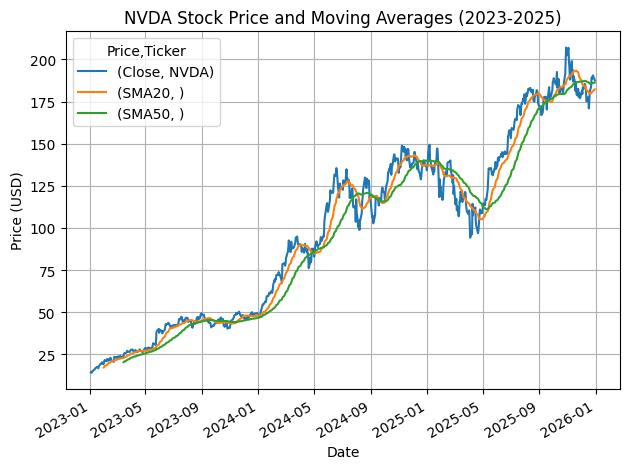

In [8]:
# @title {"display-mode":"form"}
# Plot closing price and moving averages
to_plot = ["Close", "SMA20", "SMA50"]
data[to_plot].plot(title="NVDA Stock Price and Moving Averages (2023-2025)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.grid(True)
plt.show()

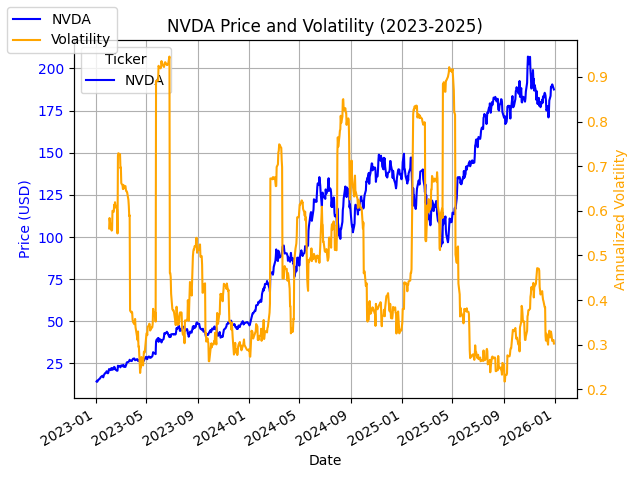

In [9]:
# @title {"display-mode":"form"}
# Plot price and volatility on dual axes
fig, ax1 = plt.subplots()
data["Close"].plot(ax=ax1, label="Close Price", color="blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price (USD)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(True)

ax2 = ax1.twinx()
data["vol"].plot(ax=ax2, label="Volatility", color="orange")
ax2.set_ylabel("Annualized Volatility", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("NVDA Price and Volatility (2023-2025)")
fig.legend(loc="upper left")
plt.tight_layout()
plt.show()

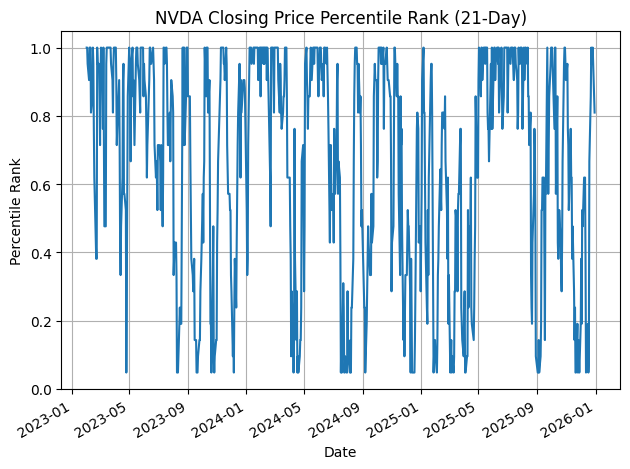

In [10]:
#@title {"display-mode":"form"}
# Plot percentile rank
data["pct_rank"].plot(title="NVDA Closing Price Percentile Rank (21-Day)")
plt.xlabel("Date")
plt.ylabel("Percentile Rank")
plt.tight_layout()
plt.grid(True)
plt.show()

##### **Set Up Email Notifications**

In [11]:
#@title {"display-mode":"form"}
import smtplib
from email.mime.text import MIMEText

def send_email(subject, body):
    sender = "your_email@gmail.com"  # Replace with your email
    receiver = "receiver_email@gmail.com"  # Replace with recipient email
    password = "your_app_password"  # Use Gmail app-specific password (enable 2FA, generate at myaccount.google.com/security)
    msg = MIMEText(body)
    msg['Subject'] = subject
    msg['From'] = sender
    msg['To'] = receiver
    try:
        with smtplib.SMTP('smtp.gmail.com', 587) as server:
            server.starttls()
            server.login(sender, password)
            server.send_message(msg)
        print("Email sent successfully!")
    except Exception as e:
        print(f"Error sending email: {e}")

# Check conditions on the latest data point
latest = data.iloc[-1]
if latest['Close'] > latest['SMA50']:
    send_email("NVDA Alert: Price Above 50-Day SMA",
               f"NVDA price (${latest['Close']:.2f}) crossed above 50-day SMA (${latest['SMA50']:.2f}) on {data.index[-1].date()}.")
if latest['vol'] > 0.5:
    send_email("NVDA Alert: High Volatility",
               f"NVDA volatility ({latest['vol']:.2f}) exceeds threshold on {data.index[-1].date()}.")

ValueError: Can only compare identically-labeled Series objects

##### **Next Steps**

- Experiment with windows (e.g., 10-day SMA or 30-day volatility)
- Add indicators like RSI or Bollinger Bands for deeper insights.